In [2]:
from pathlib import Path
import gzip
import json
from pprint import pprint
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
from stable_platform_matchings.domain.instance import Instance
import seaborn as sns

In [3]:
sns.set_theme(context="paper", style="ticks")

In [4]:
root = Path("../results/exp_4")
all_jsons = list(root.rglob("*.json.gz"))
graph_data_filename = "../data/graph_0-14960_00_new.pickle"
instance = Instance.from_yaml(Path('../data/anon_14_day_instances/2020-08-27.yaml'))

In [104]:

# ============================================================
# SETTINGS
# ============================================================

# Example:
# all_jsons = sorted(Path("results/exp_3").glob("job_*/*.json.gz"))

LC_TO_USD = instance.lc_to_usd
TRUCK_FIXED_COST = instance.truck_fixed_cost

MAX_DEVIATION_POTENTIAL = 12

DEV_POT_BINS = np.linspace(2, 12, 7)
COST_BINS = np.linspace(65, 110, 7)

ZERO_TOL = 1e-8


# ============================================================
# PLOTTING STYLE
# ============================================================

def currency_formatter(x, pos):
    return f"${x:.0f}"


plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})


# ============================================================
# LOAD PAIRED DATA
# ============================================================

data_vanilla_no_pay = []
data_vanilla_pay = []
data_structured_no_pay = []
data_structured_pay = []

for file in all_jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        aggregate_payload = json.load(f)

    job_id = aggregate_payload["job_id"]

    for payload in aggregate_payload["runs"]:

        run_index = payload["metadata"]["run_index"]

        instance_snapshot = payload["summary_vanilla_no_pay"]["instance_snapshot"]
        instance_id = instance_snapshot["instance_id"]

        epsilons = payload["sampled_inputs"]["epsilons"]
        het_costs = payload["sampled_inputs"]["het_costs"]
        intermediaries = instance_snapshot["intermediaries"]

        avg_epsilon = np.mean(list(epsilons.values()))

        treatment_results = {
            "vanilla_no_pay": payload["summary_vanilla_no_pay"]["platform_solve_result"],
            "vanilla_pay": payload["summary_vanilla_pay"]["platform_solve_result"],
            "structured_no_pay": payload["summary_structured_no_pay"]["platform_solve_result"],
            "structured_pay": payload["summary_structured_pay"]["platform_solve_result"],
        }

        total_fruit_value = sum(
            quantity * instance.fruit_price_per_ton 
            for quantity in payload["sampled_inputs"]["quantities"].values()
        )


        for treatment, solve_result in treatment_results.items():
            primary_result = solve_result["primary_result"]

            max_int_result = solve_result[
                "max_intermediary_welfare_result"
            ]

            max_farmer_result = solve_result[
                "max_farmer_welfare_result"
            ]

            platform_profit = (
                max_int_result["platform_profit"]
            )

            max_intermediary_welfare = (
                max_int_result["intermediary_welfare"]
            )

            min_farmer_welfare = (
                max_int_result["farmer_welfare"]
            )

            row = {
                "job_id": job_id,
                "run_index": run_index,
                "avg_epsilon": avg_epsilon,
                "platform_profit_pct": platform_profit / total_fruit_value,
                "max_intermediary_welfare_pct": max_intermediary_welfare / total_fruit_value,
                "min_farmer_welfare_pct": min_farmer_welfare / total_fruit_value
            }

            if treatment == "vanilla_no_pay":
                data_vanilla_no_pay.append(row)
            elif treatment == "vanilla_pay":
                data_vanilla_pay.append(row)
            elif treatment == "structured_no_pay":
                data_structured_no_pay.append(row)
            else:
                data_structured_pay.append(row)


df_vanilla_no_pay = pd.DataFrame(data_vanilla_no_pay)
df_vanilla_pay = pd.DataFrame(data_vanilla_pay)
df_structured_no_pay = pd.DataFrame(data_structured_no_pay)
df_structured_pay = pd.DataFrame(data_structured_pay)

In [105]:
actual_costs_platform = {
    0: 0.0775829869015126,
    1: 0.07768902868743288,
    2: 0.07792714074761442,
    3: 0.07779050019770295,
    4: 0.07780432119364723,
    5: 0.07780432119364725,
    6: 0.07758298690151258,
    7: 0.07758298690151257,
    8: 0.07758298690151258,
    9: 0.0775829869015126,
 }

actual_costs_improvement = {i: actual_costs_platform[i] - actual_costs_platform[0] for i in range(1, 10)}

actual_perc_platform = {
    0: 0.09959740695143612,
    1: 0.044517655245960054,
    2: 0.022845478696154217,
    3: 0.011845342163052535,
    4: 0.005042216382378989,
    5: 0.0009595428605521555,
    6: -0.002270061056467741,
    7: -0.004516052387438745,
    8: -0.005835568402234102,
    9: -0.007022154488203626
 }

actual_max_int = {
    0: 0.32758953661755996,
    1: 0.04175691614041955,
    2: 0.02060091126517644,
    3: 0.013039289559810586,
    4: 0.009350912870058112,
    5: 0.007924168304404811,
    6: 0.00772484422378011,
    7: 0.007443614889069343,
    8: 0.0063391957909994575,
    9: 0.005711990106601736
 }

actual_min_int = {
    0: 0.0,
    1: 0.01478574070810623,
    2: 0.007534357335050608,
    3: 0.007899933576455203,
    4: 0.005905858766726449,
    5: 0.006235383720283765,
    6: 0.0058198497457951585,
    7: 0.0073826381391337735,
    8: 0.006322061118747919,
    9: 0.00571137535532129
 }

actual_min_farmer = {
    0: 0.4952300812484759,
    1: 0.8360364116451723,
    2: 0.8786264810100395,
    3: 0.8973248797984186,
    4: 0.9078025612729003,
    5: 0.9133119793603803,
    6: 0.9169622416501595,
    7: 0.9194894623158415,
    8: 0.9219133974287067,
    9: 0.9237271891990739
 }

actual_max_farmer = {
    0: 0.8228196178660359,
    1: 0.8630075870774853,
    2: 0.8916930349401653,
    3: 0.9024642357817737,
    4: 0.911247615376232,
    5: 0.9150007639445015,
    6: 0.9188672361281446,
    7: 0.9195504390657769,
    8: 0.9219305321009583,
    9: 0.9237278039503545
 }



In [106]:
pair_cols = [
    "job_id",
    "run_index",
    "avg_epsilon"
]

paired = df_vanilla_no_pay.merge(
    df_vanilla_pay,
    on=pair_cols,
    suffixes=("_no_pay", "_pay"),
    validate="one_to_one",
)

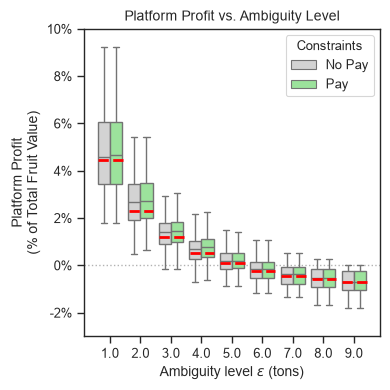

In [118]:
profit_data = paired.melt(
    id_vars='avg_epsilon', 
    value_vars=['platform_profit_pct_no_pay', 'platform_profit_pct_pay'], 
    var_name='Constraints', 
    value_name='Profit'
)
profit_data = profit_data.query("avg_epsilon >= 1.0")

plt.figure(figsize=(4, 4))

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

palette = {
    "No Pay": "lightgray", 
    "Pay": "lightgreen"
}

profit_data['Constraints'] = profit_data['Constraints'].map({
    'platform_profit_pct_no_pay': 'No Pay', 
    'platform_profit_pct_pay': 'Pay', 
})


ax = sns.boxplot(
    data=profit_data, 
    x="avg_epsilon", 
    y="Profit", 
    hue="Constraints",
    zorder=1, 
    showfliers=False,
    palette=palette
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)


for i, category in enumerate(list(range(1, 10))):
    obs = actual_perc_platform.get(category, None)
    if obs is not None:
        plt.plot(
            [i - 0.38, i + 0.42], 
            [obs, obs], 
            color="red", 
            linewidth=2, 
            linestyle="--",  # Dashed line for the average
            label="Average (observed)" if i == 0 else "", 
            zorder=10
        )


ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

plt.ylabel("Platform Profit\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Platform Profit vs. Ambiguity Level")

plt.ylim(-0.03, 0.1)
plt.tight_layout()
plt.show()

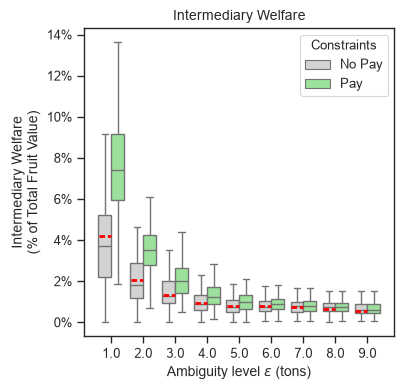

In [119]:
int_welfare = paired.melt(
    id_vars='avg_epsilon', 
    value_vars=['max_intermediary_welfare_pct_no_pay', 'max_intermediary_welfare_pct_pay'], 
    var_name='Constraints', 
    value_name='Welfare'
)
int_welfare = int_welfare[int_welfare.avg_epsilon >= 1]

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})


int_welfare['Constraints'] = int_welfare['Constraints'].map({
    'max_intermediary_welfare_pct_no_pay': 'No Pay', 
    'max_intermediary_welfare_pct_pay': 'Pay'
})

palette = {
    "No Pay": "lightgray", 
    "Pay": "lightgreen"
}

plt.figure(figsize=(4, 4))
ax = sns.boxplot(
    data=int_welfare, 
    x="avg_epsilon", 
    y="Welfare", 
    hue="Constraints", 
    palette=palette, 
    showfliers=False
)

for i, category in enumerate(sorted(int_welfare["avg_epsilon"].unique())):
    obs_max = actual_max_int.get(category, None)
    obs_min = actual_min_int.get(category, None)
    if obs_max is not None:
        line, = plt.plot(
            [i - 0.38, i - 0.02], [obs_max, obs_max], 
            color="red", linewidth=2, linestyle="--", 
            label="Average (observed)" if i == 0 else "", zorder=10
        )
        line.set_dashes([2, 1])


ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))


plt.ylabel("Intermediary Welfare\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Intermediary Welfare")
plt.show()

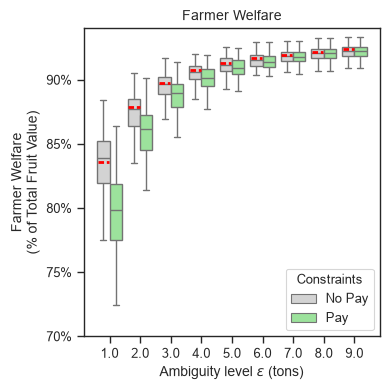

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Set color palette manually to ensure consistency
palette = {
    "No Pay": "lightgray", 
    "Pay": "lightgreen"
}

# Melt the dataframe
farmer_welfare = paired.melt(
    id_vars='avg_epsilon', 
    value_vars=['min_farmer_welfare_pct_no_pay', 'min_farmer_welfare_pct_pay'], 
    var_name='Constraints', 
    value_name='Welfare'
)
farmer_welfare = farmer_welfare[farmer_welfare.avg_epsilon >= 1]

# Improve category names for legend
farmer_welfare['Constraints'] = farmer_welfare['Constraints'].map({
    'min_farmer_welfare_pct_no_pay': 'No Pay', 
    'min_farmer_welfare_pct_pay': 'Pay'
})

# Create boxplot
plt.figure(figsize=(4, 4))  # Adjusted figsize
ax = sns.boxplot(
    data=farmer_welfare, 
    x="avg_epsilon", 
    y="Welfare", 
    hue="Constraints", 
    palette=palette, 
    showfliers=False
)

# Overlay actual data lines with red dashed lines for averages
for i, category in enumerate(sorted(farmer_welfare["avg_epsilon"].unique())):
    obs_max = actual_max_farmer.get(category, None)
    obs_min = actual_min_farmer.get(category, None)
    if obs_min is not None:
            line, = plt.plot(
                [i - 0.38, i - 0.02], [obs_min, obs_min], 
                color="red", linewidth=2, linestyle="--", 
                label=None, zorder=10
            )
            line.set_dashes([2, 1])  # Custom dash pattern: short dash, small gap
            
# Format y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Labeling
plt.ylabel("Farmer Welfare\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Farmer Welfare")

plt.ylim(0.7, 0.94)
plt.tight_layout()
plt.show()